# NB2: Pan-GWAS and Functional Enrichment

**FunPan Aspergillus Pangenome Project**

Pipeline steps:

1. One-vs-rest phenotype contrasts per species
2. Linear mixed-model association tests with a kinship random effect, per species, contrast and feature layer (PAV, CNV, BGC PAV, GCF PAV, GCF CNV)
3. Power analysis per contrast
4. Functional enrichment of significant orthogroups
5. Co-localisation of significant orthogroups with BGC regions
6. Cross-species summary of significant associations

Inputs are read from `NB0_Results/` (phenotype table) and `NB1_Results/` (PAV, CNV,
kinship and BGC/GCF matrices, orthogroup annotations). Outputs are saved under
`NB2_Results/`.

Analysis functions live in `funpan_utils.py` and `funpan_gwas.py`. Sections 2 to 8
each open with a bootstrap cell that sets the paths, imports those modules and
reloads that section's inputs, so any section can be run on its own from a fresh
kernel. Edit the path block at the top of a bootstrap cell to point the notebook at
your own directories.

Set `FORCE = True` in any bootstrap cell to ignore cached tables and recompute from
source.

---
## Section 1: Configuration

- Paths, species list, feature layers, annotation layers and the FDR threshold
- `FORCE` controls whether cached tables are reused or recomputed
- Reports which NB0 and NB1 inputs are present and creates the output directories before anything runs

In [1]:
import sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = Path('/datadrive/Analysis')
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as utils
import funpan_gwas as gwas

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES           = utils.SPECIES_LIST
FEATURE_LAYERS    = ['pav', 'cnv', 'bgc_pav', 'gcf_pav', 'gcf_cnv']
ANNOTATION_LAYERS = ['COG_category', 'PFAMs', 'CAZy', 'KEGG_ko', 'KEGG_Pathway',
                     'KEGG_TC', 'GOs', 'interpro_IPR', 'EC', 'dbcan_Substrate']
FDR_THRESHOLD     = 0.05

# Reports which inputs exist and creates the output directories.
# Nothing is computed or written beyond those directories.
status = gwas.nb2_preflight(SPECIES, NB0_RESULTS, NB1_RESULTS, NB2_RESULTS)

NB2 inputs
  NB0 phenotype table: found
  -> /datadrive/Analysis/NB0_Results/phenotype_classified_for_gwas.csv
  NB1 matrices under: /datadrive/Analysis/NB1_Results

          pav cnv kinship bgc_pav gcf_pav gcf_cnv og_consensus
species                                                       
fumigatus  ok  ok      ok      ok      ok      ok           ok
flavus     ok  ok      ok      ok      ok      ok           ok
niger      ok  ok      ok      ok      ok      ok           ok
oryzae     ok  ok      ok      ok      ok      ok           ok

All inputs present.


### 1.1 Phenotype labels

- Phenotype table from NB0, one row per genome

In [2]:
pheno_classified = pd.read_csv(NB0_RESULTS / 'phenotype_classified_for_gwas.csv', index_col=0)
print(f'Phenotype classification table: {pheno_classified.shape}')
display(pheno_classified.head())

Phenotype classification table: (206, 68)


,Assembly Name,Organism Name,Organism Taxonomic ID,ANI Check status,Organism Infraspecific Names Breed,Organism Infraspecific Names Strain,Organism Infraspecific Names Cultivar,Organism Infraspecific Names Ecotype,Organism Infraspecific Names Isolate,Organism Infraspecific Names Sex,...,PhenotypeScores,PhenotypeMatched,FieldProvenance,NegationsApplied,IsolationClass,IsolationSubclass,IsolationSubtype,ClassConfidence,ClassificationConfidence,UsageClass
Assembly Accession,,,,,,,,,,,,,,,,,,,,,
GCA_000150145.1,ASM15014v1,Aspergillus fumigatus A1163,451804,NaN,NaN,A1163,NaN,NaN,NaN,NaN,...,"{""Human-pathogenic"": 10.0, ""Animal-pathogenic""...","{""Human-pathogenic"": [""Established strain: Asp...","{""Provenance:Clinical"": [""description"", ""comme...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
GCA_001599455.1,JCM_10253_assembly_v001,Aspergillus fumigatus var. fumigatus,41122,NaN,NaN,JCM 10253,NaN,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""description"", ""...",[],Environmental,Environmental,Environmental,low,low,Wild-type
GCA_001715275.2,ASM171527v2,Aspergillus fumigatus,746128,NaN,NaN,LMB-35Aa,NaN,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""isolation_sourc...",[],Environmental,Environmental,Environmental,low,low,Wild-type
GCA_015572005.1,ASM1557200v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA A,NaN,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
GCA_015572015.1,ASM1557201v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA B,NaN,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic


### 1.2 Per-species input matrices

- `load_all_species_gwas_data()` reads the NB0 phenotypes and the NB1 PAV, CNV, kinship, SNP PC, BGC/GCF and orthogroup annotation tables for each species

In [3]:
species_data = gwas.load_all_species_gwas_data(
    SPECIES, NB0_RESULTS, NB1_RESULTS, ANNOTATION_LAYERS
)

fumigatus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
flavus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
niger: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
oryzae: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']


---
## Section 2: One-vs-Rest Phenotype Contrasts

- `build_all_phenotype_contrasts()` builds one binary contrast per phenotype per species, for example `human_pathogenic_vs_rest`
- Cached to `NB2_Results/{sp}/phenotypes/pheno_{contrast}.tsv`
- Requires Section 1.2

In [4]:
# Standalone bootstrap: run this cell to use Section 2 from a fresh kernel.
import sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = Path('/datadrive/Analysis')
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as utils
import funpan_gwas as gwas

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES           = utils.SPECIES_LIST
FEATURE_LAYERS    = ['pav', 'cnv', 'bgc_pav', 'gcf_pav', 'gcf_cnv']
ANNOTATION_LAYERS = ['COG_category', 'PFAMs', 'CAZy', 'KEGG_ko', 'KEGG_Pathway',
                     'KEGG_TC', 'GOs', 'interpro_IPR', 'EC', 'dbcan_Substrate']
FDR_THRESHOLD     = 0.05

species_data = gwas.load_all_species_gwas_data(
    SPECIES, NB0_RESULTS, NB1_RESULTS, ANNOTATION_LAYERS
)

fumigatus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
flavus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
niger: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
oryzae: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']


In [5]:
species_contrasts = gwas.build_all_phenotype_contrasts(
    SPECIES, species_data, NB2_RESULTS, force=FORCE
)

fumigatus: loaded 2 cached contrasts
flavus: loaded 3 cached contrasts
niger: loaded 2 cached contrasts

oryzae -- 0 contrasts:


---
## Section 3: Association Testing

- `run_all_associations()` fits an EMMA-style linear mixed model with the kinship matrix as random effect, for every species, contrast and feature layer
- Benjamini-Hochberg FDR correction within each test
- Cached to `NB2_Results/{sp}/pangwas_results/{layer}_assoc_{contrast}.tsv`
- Requires Section 2

In [6]:
# Standalone bootstrap: run this cell to use Section 3 from a fresh kernel.
import sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = Path('/datadrive/Analysis')
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as utils
import funpan_gwas as gwas

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES           = utils.SPECIES_LIST
FEATURE_LAYERS    = ['pav', 'cnv', 'bgc_pav', 'gcf_pav', 'gcf_cnv']
ANNOTATION_LAYERS = ['COG_category', 'PFAMs', 'CAZy', 'KEGG_ko', 'KEGG_Pathway',
                     'KEGG_TC', 'GOs', 'interpro_IPR', 'EC', 'dbcan_Substrate']
FDR_THRESHOLD     = 0.05

species_data = gwas.load_all_species_gwas_data(
    SPECIES, NB0_RESULTS, NB1_RESULTS, ANNOTATION_LAYERS
)
species_contrasts = gwas.build_all_phenotype_contrasts(
    SPECIES, species_data, NB2_RESULTS, force=FORCE
)

fumigatus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
flavus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
niger: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
oryzae: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
fumigatus: loaded 2 cached contrasts
flavus: loaded 3 cached contrasts
niger: loaded 2 cached contrasts

oryzae -- 0 contrasts:


In [7]:
all_results = gwas.run_all_associations(
    SPECIES, species_contrasts, species_data, NB2_RESULTS,
    FEATURE_LAYERS, ANNOTATION_LAYERS, FDR_THRESHOLD, force=FORCE
)


fumigatus: running association tests

  Contrast: human_pathogenic_vs_rest
    Layer: pav (88 features) ... cached (92 significant)
    Layer: cnv (88 features) ... cached (88 significant)
    Layer: bgc_pav (88 features) ... cached (0 significant)
    Layer: gcf_pav (88 features) ... cached (3 significant)
    Layer: gcf_cnv (88 features) ... cached (3 significant)

  Contrast: environmental_vs_rest
    Layer: pav (88 features) ... cached (92 significant)
    Layer: cnv (88 features) ... cached (88 significant)
    Layer: bgc_pav (88 features) ... cached (0 significant)
    Layer: gcf_pav (88 features) ... cached (3 significant)
    Layer: gcf_cnv (88 features) ... cached (3 significant)

flavus: running association tests

  Contrast: plant_pathogenic_vs_rest
    Layer: pav (70 features) ... cached (117 significant)
    Layer: cnv (70 features) ... cached (98 significant)
    Layer: bgc_pav (70 features) ... cached (0 significant)
    Layer: gcf_pav (70 features) ... cached (4 signif

### 3.1 GCF association annotation

- Joins `{sp}_gcf_annotation.tsv` from NB1 onto every GCF association table
- Adds BGC class, MIBiG evidence and family size to each `FAM_*` feature
- Writes `*_assoc_*_annotated.tsv` beside the originals

In [8]:
import funpan_pangenome as fpp

gcf_annotation = {
    sp: pd.read_csv(NB1_RESULTS / sp / f'{sp}_gcf_annotation.tsv', sep='\t')
    for sp in SPECIES
    if (NB1_RESULTS / sp / f'{sp}_gcf_annotation.tsv').exists()
}
missing = [sp for sp in SPECIES if sp not in gcf_annotation]
if missing:
    print(f'No GCF annotation for {missing}: run NB1 section 8.1 first.')

for (sp, contrast, layer), df in sorted(all_results.items()):
    if not layer.startswith('gcf') or sp not in gcf_annotation:
        continue
    annotated = fpp.annotate_gcf_associations(df, gcf_annotation[sp])
    dest = NB2_RESULTS / sp / 'pangwas_results' / f'{layer}_assoc_{contrast}_annotated.tsv'
    annotated.to_csv(dest, sep='\t', index=False)
    n_sig = int(annotated['significant'].sum()) if 'significant' in annotated else 0
    n_gap = int(annotated['antismash_class'].isna().sum()) if 'antismash_class' in annotated else len(annotated)
    print(f'{sp:10s} {contrast:32s} {layer:8s} -> {dest.name}  ({n_sig} significant, {n_gap} unannotated)')

flavus     environmental_vs_rest            gcf_cnv  -> gcf_cnv_assoc_environmental_vs_rest_annotated.tsv  (0 significant, 0 unannotated)
flavus     environmental_vs_rest            gcf_pav  -> gcf_pav_assoc_environmental_vs_rest_annotated.tsv  (0 significant, 0 unannotated)
flavus     human_pathogenic_vs_rest         gcf_cnv  -> gcf_cnv_assoc_human_pathogenic_vs_rest_annotated.tsv  (1 significant, 0 unannotated)
flavus     human_pathogenic_vs_rest         gcf_pav  -> gcf_pav_assoc_human_pathogenic_vs_rest_annotated.tsv  (1 significant, 0 unannotated)
flavus     plant_pathogenic_vs_rest         gcf_cnv  -> gcf_cnv_assoc_plant_pathogenic_vs_rest_annotated.tsv  (4 significant, 0 unannotated)
flavus     plant_pathogenic_vs_rest         gcf_pav  -> gcf_pav_assoc_plant_pathogenic_vs_rest_annotated.tsv  (4 significant, 0 unannotated)
fumigatus  environmental_vs_rest            gcf_cnv  -> gcf_cnv_assoc_environmental_vs_rest_annotated.tsv  (3 significant, 0 unannotated)
fumigatus  environment

#### 3.1.1 Significant GCF associations

- Every FDR-significant GCF hit with its class and MIBiG evidence
- `mibig_in_family`: MIBiG reference clustered into the family by BiG-SCAPE
- `kcb_compound` and `kcb_support`: top knownclusterblast hit and its coverage
- Writes `gcf_significant_annotated.tsv`

In [9]:
gcf_sig = fpp.collect_significant_gcf_associations(SPECIES, NB2_RESULTS)
gcf_sig.to_csv(NB2_RESULTS / 'gcf_significant_annotated.tsv', sep='\t', index=False)

print(f'{len(gcf_sig)} significant GCF associations')
gcf_sig.fillna('-')

32 significant GCF associations


,species,contrast,layer,GCF,class,direction,beta,qvalue,n_strains,mibig_in_family,kcb_compound,kcb_support
0,flavus,human_pathogenic_vs_rest,gcf_cnv,FAM_00077,NRPS,gained,0.423,7.085287e-04,49,BGC0001123,aspirochlorine,0.906
1,flavus,human_pathogenic_vs_rest,gcf_pav,FAM_00077,NRPS,gained,0.603,2.475530e-06,49,BGC0001123,aspirochlorine,0.906
2,flavus,plant_pathogenic_vs_rest,gcf_cnv,FAM_00152,NI-siderophore.NRPS,gained,0.721,4.340972e-13,20,-,aspirochlorine,1.000
3,flavus,plant_pathogenic_vs_rest,gcf_cnv,FAM_00059,NRPS-like,gained,0.612,1.170647e-11,13,-,-,0.000
4,flavus,plant_pathogenic_vs_rest,gcf_cnv,FAM_00077,NRPS,lost,-0.328,3.322215e-04,49,BGC0001123,aspirochlorine,0.906
5,flavus,plant_pathogenic_vs_rest,gcf_cnv,FAM_00044,terpene,lost,-0.407,2.756018e-02,26,BGC0001995,heptelidic acid,1.000
6,flavus,plant_pathogenic_vs_rest,gcf_pav,FAM_00152,NI-siderophore.NRPS,gained,0.721,4.340972e-13,20,-,aspirochlorine,1.000
7,flavus,plant_pathogenic_vs_rest,gcf_pav,FAM_00059,NRPS-like,gained,0.612,1.170647e-11,13,-,-,0.000
8,flavus,plant_pathogenic_vs_rest,gcf_pav,FAM_00077,NRPS,lost,-0.468,1.366171e-06,49,BGC0001123,aspirochlorine,0.906
9,flavus,plant_pathogenic_vs_rest,gcf_pav,FAM_00044,terpene,lost,-0.407,2.756018e-02,26,BGC0001995,heptelidic acid,1.000


### 3.2 Significant hits per test

- Tested and significant counts, with the genomic inflation factor, per species, contrast and feature layer

In [10]:
summary_df = gwas.association_summary_table(all_results)
display(summary_df)

,species,contrast,feature_layer,n_tested,n_significant,lambda_gc
0,flavus,environmental_vs_rest,bgc_pav,0,0,NaN
1,flavus,environmental_vs_rest,cnv,3011,27,0.003
2,flavus,environmental_vs_rest,gcf_cnv,85,0,0.004
3,flavus,environmental_vs_rest,gcf_pav,85,0,0.004
4,flavus,environmental_vs_rest,pav,3011,28,0.004
5,flavus,human_pathogenic_vs_rest,bgc_pav,0,0,NaN
6,flavus,human_pathogenic_vs_rest,cnv,3011,49,0.027
7,flavus,human_pathogenic_vs_rest,gcf_cnv,85,1,0.054
8,flavus,human_pathogenic_vs_rest,gcf_pav,85,1,0.054
9,flavus,human_pathogenic_vs_rest,pav,3011,62,0.047


### 3.3 Volcano matrix

- Rows are species and phenotype-of-interest contrasts; environmental contrasts are excluded
- Columns are the PAV, CNV and BGC PAV layers
- The top hits by absolute effect size are labelled in each panel
- Saved to `NB2_Results/volcano_grid_focus.png`

Saved: /datadrive/Analysis/NB2_Results/volcano_grid_focus.png
Rows (species x phenotype-of-interest): 4   Columns (layers): 3


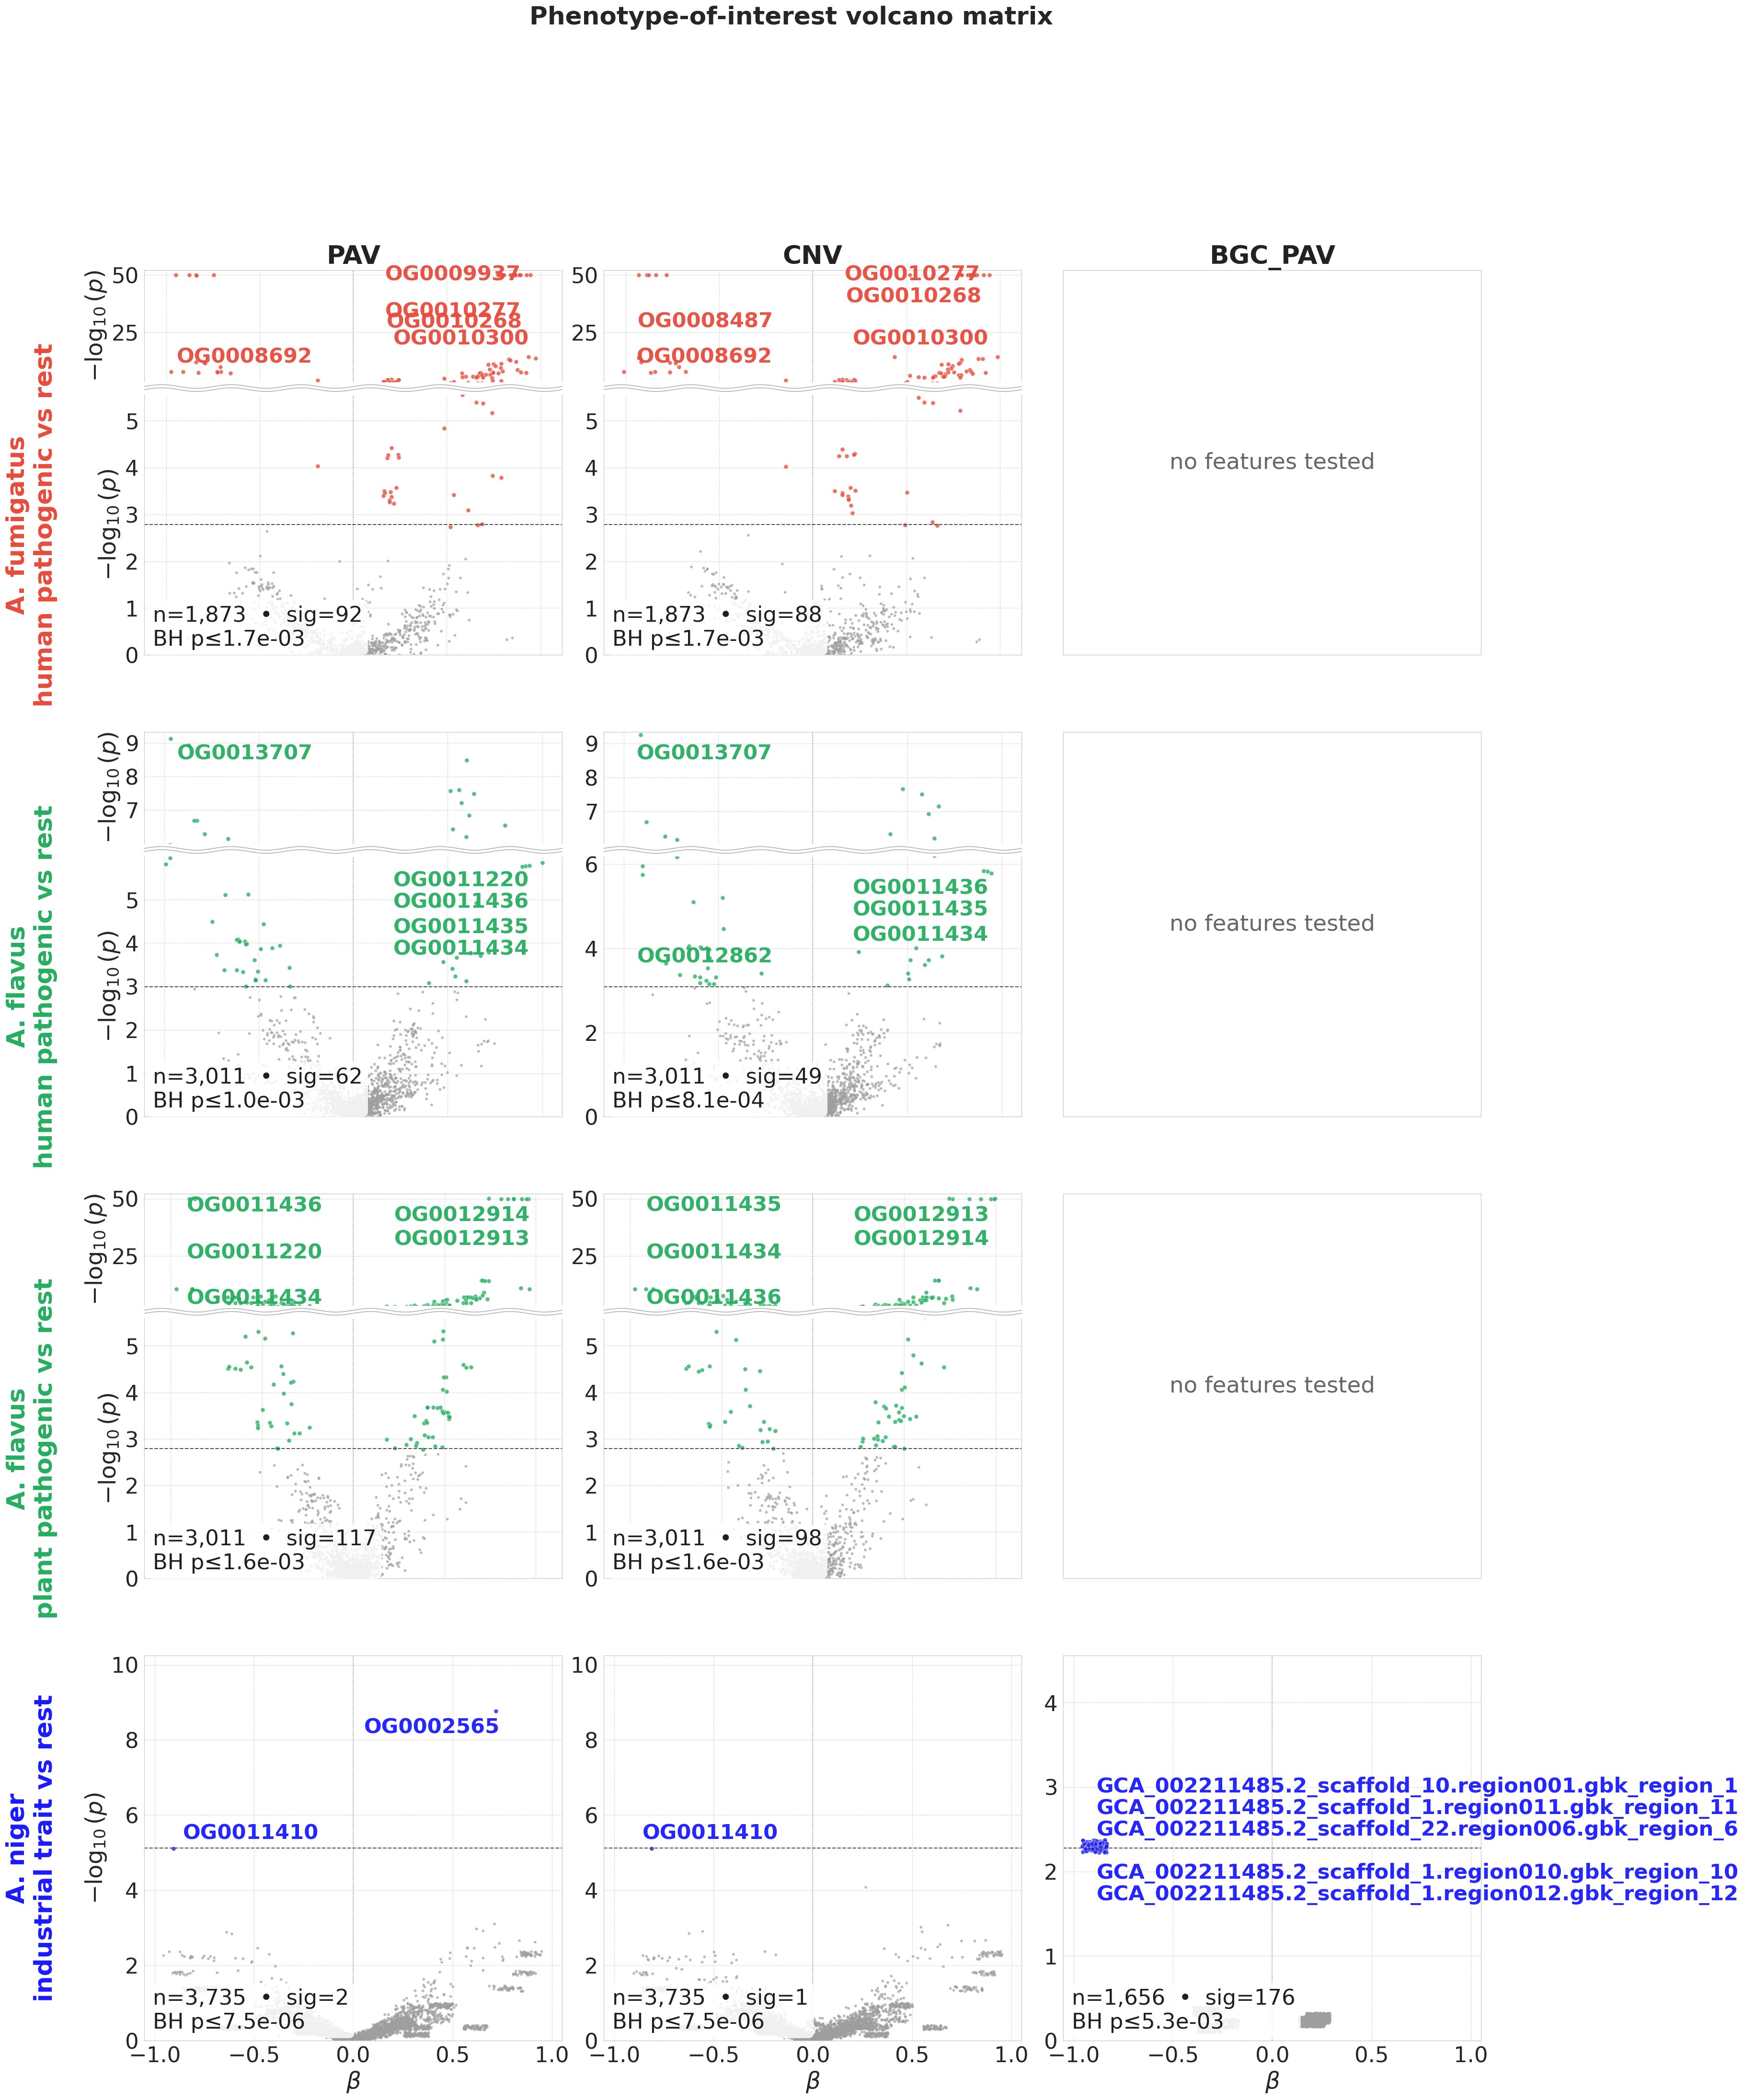

In [11]:
# --- Tweakable parameters ---
FONTSIZE           = 30
DPI                = 800
FIG_W_PER_LAYER    = 10.0
FIG_H_PER_ROW      = 10.0
N_TOP_LABELS       = 5
Q_THRESHOLD        = 0.05
Y_MAX_CLIP         = 50      # -log10(p) values above this are clipped
LAYERS             = ['pav', 'cnv', 'bgc_pav']
EXCLUDE_CONTRASTS  = ['environmental_vs_rest']
JITTER_X           = 0.06    # visual only
JITTER_Y           = 0.06    # visual only
JITTER_SEED        = 0
Y_MIN_HALF_RANGE   = 1.0
GAP_TRIGGER_FACTOR = 1.25    # split the y-axis when y_max exceeds this x the centred limit
UPPER_HEIGHT_RATIO = 0.30    # share of panel height for the upper sub-axis when split
OVERFLOW_PADDING   = 0.05    # headroom around the upper sub-axis range

VOLCANO_FIG = NB2_RESULTS / 'volcano_grid_focus.png'

fig_volcano = gwas.plot_focus_volcano_grid(
    SPECIES, NB2_RESULTS,
    out_path=VOLCANO_FIG,
    fontsize=FONTSIZE,
    dpi=DPI,
    fig_w_per_layer=FIG_W_PER_LAYER,
    fig_h_per_row=FIG_H_PER_ROW,
    n_top_labels=N_TOP_LABELS,
    q_threshold=Q_THRESHOLD,
    y_max_clip=Y_MAX_CLIP,
    layers=LAYERS,
    exclude_contrasts=EXCLUDE_CONTRASTS,
    jitter_x=JITTER_X,
    jitter_y=JITTER_Y,
    jitter_seed=JITTER_SEED,
    y_min_half_range=Y_MIN_HALF_RANGE,
    gap_trigger_factor=GAP_TRIGGER_FACTOR,
    upper_height_ratio=UPPER_HEIGHT_RATIO,
    overflow_padding=OVERFLOW_PADDING,
)
plt.show()

---
## Section 4: Power Analysis

- `run_power_analysis_grid()` simulates Fisher's exact test power for each contrast's case/control split, and the minimum detectable odds ratio at 80% power
- Cached to `NB2_Results/power_analysis_results.tsv`
- Requires Section 2

In [12]:
# Standalone bootstrap: run this cell to use Section 4 from a fresh kernel.
import sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = Path('/datadrive/Analysis')
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as utils
import funpan_gwas as gwas

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES           = utils.SPECIES_LIST
FEATURE_LAYERS    = ['pav', 'cnv', 'bgc_pav', 'gcf_pav', 'gcf_cnv']
ANNOTATION_LAYERS = ['COG_category', 'PFAMs', 'CAZy', 'KEGG_ko', 'KEGG_Pathway',
                     'KEGG_TC', 'GOs', 'interpro_IPR', 'EC', 'dbcan_Substrate']
FDR_THRESHOLD     = 0.05

species_data = gwas.load_all_species_gwas_data(
    SPECIES, NB0_RESULTS, NB1_RESULTS, ANNOTATION_LAYERS
)
species_contrasts = gwas.build_all_phenotype_contrasts(
    SPECIES, species_data, NB2_RESULTS, force=FORCE
)

fumigatus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
flavus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
niger: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
oryzae: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
fumigatus: loaded 2 cached contrasts
flavus: loaded 3 cached contrasts
niger: loaded 2 cached contrasts

oryzae -- 0 contrasts:


In [13]:
power_df = gwas.run_power_analysis_grid(
    SPECIES, species_contrasts, NB2_RESULTS, FDR_THRESHOLD, force=FORCE
)
display(power_df)

Loaded cached power analysis (35 rows) from /datadrive/Analysis/NB2_Results/power_analysis_results.tsv


,species,contrast,n_cases,n_controls,ratio,target_OR,power
0,fumigatus,human_pathogenic_vs_rest,37,48,37:48,2.0,0.2439
1,fumigatus,human_pathogenic_vs_rest,37,48,37:48,3.0,0.5831
2,fumigatus,human_pathogenic_vs_rest,37,48,37:48,5.0,0.9150
3,fumigatus,human_pathogenic_vs_rest,37,48,37:48,10.0,0.9986
4,fumigatus,human_pathogenic_vs_rest,37,48,37:48,min_OR@80%power,3.6400
5,fumigatus,environmental_vs_rest,48,37,48:37,2.0,0.2220
6,fumigatus,environmental_vs_rest,48,37,48:37,3.0,0.5716
7,fumigatus,environmental_vs_rest,48,37,48:37,5.0,0.9218
8,fumigatus,environmental_vs_rest,48,37,48:37,10.0,0.9985
9,fumigatus,environmental_vs_rest,48,37,48:37,min_OR@80%power,3.7000


### 4.1 Power curves

- Power against odds ratio for every contrast
- Cached to `NB2_Results/power_curves.tsv`; saved to `NB2_Results/power_analysis_curves.png`

Loaded cached power curves from /datadrive/Analysis/NB2_Results/power_curves.tsv
Saved: /datadrive/Analysis/NB2_Results/power_analysis_curves.png


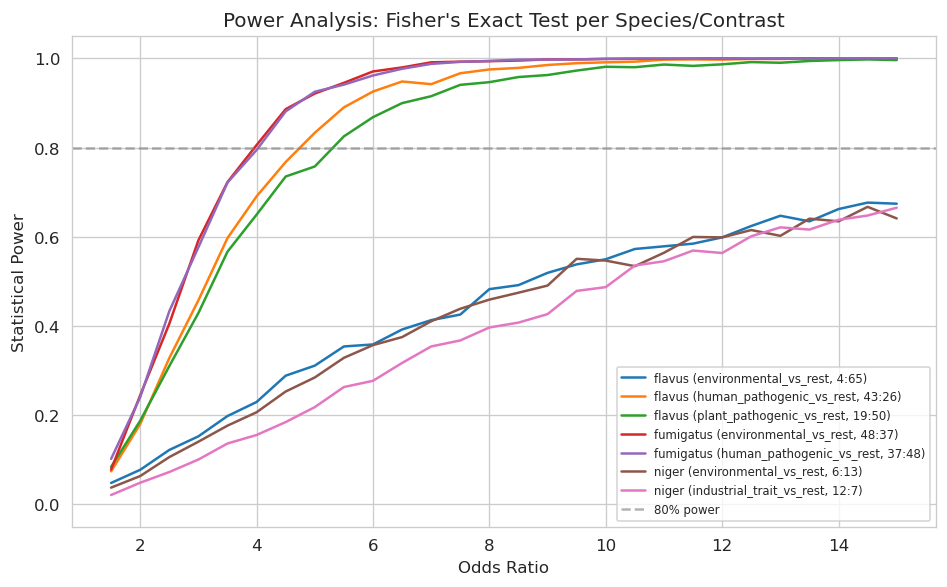

In [14]:
# --- Tweakable parameters ---
OR_RANGE  = np.arange(1.5, 15.5, 0.5)
GENE_FREQ = 0.2
N_SIM     = 2000

curves_df = gwas.compute_power_curves(
    SPECIES, species_contrasts, NB2_RESULTS, FDR_THRESHOLD,
    or_range=OR_RANGE, gene_freq=GENE_FREQ, n_sim=N_SIM, force=FORCE
)
fig_curves = gwas.plot_power_curves(
    curves_df, out_path=NB2_RESULTS / 'power_analysis_curves.png'
)
plt.show()

### 4.2 Underpowered contrasts figure

- Minimum detectable odds ratio per phenotype-of-interest contrast; environmental contrasts are excluded
- Bars above the threshold are grey, the rest green
- Saved to `NB2_Results/underpowered_contrasts_nonenv.png`

Saved: /datadrive/Analysis/NB2_Results/underpowered_contrasts_nonenv.png


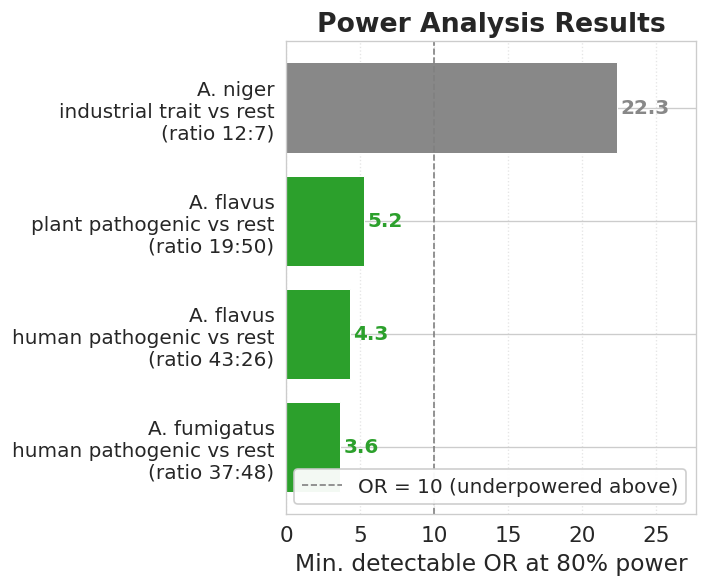


Min OR table (non-environmental contrasts):
  A. fumigatus  | human_pathogenic_vs_rest  | ratio 37:48   | min OR = 3.64
  A. flavus     | human_pathogenic_vs_rest  | ratio 43:26   | min OR = 4.28
  A. flavus     | plant_pathogenic_vs_rest  | ratio 19:50   | min OR = 5.25
  A. niger      | industrial_trait_vs_rest  | ratio 12:7    | min OR = 22.33 UNDERPOWERED


In [15]:
# --- Tweakable parameters ---
FONTSIZE               = 14
DPI                    = 800
FIGSIZE                = (6.0, 5.0)
EXCLUDE_CONTRASTS      = ['environmental_vs_rest']
UNDERPOWERED_THRESHOLD = 10.0   # minimum detectable OR above this is drawn grey

fig_power, underpowered_table = gwas.plot_underpowered_contrasts(
    NB2_RESULTS,
    out_path=NB2_RESULTS / 'underpowered_contrasts_nonenv.png',
    fontsize=FONTSIZE,
    dpi=DPI,
    figsize=FIGSIZE,
    exclude_contrasts=EXCLUDE_CONTRASTS,
    underpowered_threshold=UNDERPOWERED_THRESHOLD,
)
plt.show()

if underpowered_table is not None:
    print('\nMin OR table (non-environmental contrasts):')
    for _, r in underpowered_table.iterrows():
        flag = ' UNDERPOWERED' if r['underpowered'] else ''
        print(f"  A. {r['species']:<10} | {r['contrast']:<25} | "
              f"ratio {r['ratio']:<7} | min OR = {r['min_OR']:.2f}{flag}")

---
## Section 5: Functional Enrichment

- `run_functional_enrichment_all()` tests significant PAV and CNV orthogroups for over-representation in each annotation layer (Fisher's exact test, FDR within each layer)
- Saved to `NB2_Results/{sp}/{sp}_functional_enrichment.csv`
- Requires Section 3

In [16]:
# Standalone bootstrap: run this cell to use Section 5 from a fresh kernel.
import sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = Path('/datadrive/Analysis')
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as utils
import funpan_gwas as gwas

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES           = utils.SPECIES_LIST
FEATURE_LAYERS    = ['pav', 'cnv', 'bgc_pav', 'gcf_pav', 'gcf_cnv']
ANNOTATION_LAYERS = ['COG_category', 'PFAMs', 'CAZy', 'KEGG_ko', 'KEGG_Pathway',
                     'KEGG_TC', 'GOs', 'interpro_IPR', 'EC', 'dbcan_Substrate']
FDR_THRESHOLD     = 0.05

species_data = gwas.load_all_species_gwas_data(
    SPECIES, NB0_RESULTS, NB1_RESULTS, ANNOTATION_LAYERS
)
species_contrasts = gwas.build_all_phenotype_contrasts(
    SPECIES, species_data, NB2_RESULTS, force=FORCE
)
all_results = gwas.run_all_associations(
    SPECIES, species_contrasts, species_data, NB2_RESULTS,
    FEATURE_LAYERS, ANNOTATION_LAYERS, FDR_THRESHOLD, force=FORCE
)

fumigatus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
flavus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
niger: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
oryzae: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
fumigatus: loaded 2 cached contrasts
flavus: loaded 3 cached contrasts
niger: loaded 2 cached contrasts

oryzae -- 0 contrasts:

fumigatus: running association tests

  Contrast: human_pathogenic_vs_rest
    Layer: pav (88 features) ... cached (92 significant)
    Layer: cnv (88 features) ... cached (88 significant)
    Layer: bgc_pav (88 features) ... cached (0 significant)
    Layer: gcf_pav (88 features) ... cached (3 significant)
    Layer: gcf_cnv (88 features) ... cached (3 s

In [17]:
enrichment_results = gwas.run_functional_enrichment_all(
    SPECIES, species_data, all_results, NB2_RESULTS,
    ANNOTATION_LAYERS, FDR_THRESHOLD, force=FORCE
)

fumigatus: loaded cached enrichment (662 rows)
flavus: loaded cached enrichment (1827 rows)
niger: loaded cached enrichment (1462 rows)
oryzae: no significant orthogroups, skipping enrichment.


---
## Section 6: BGC Co-localisation

- `run_bgc_colocalisation()` maps significant orthogroups onto antiSMASH BGC regions
- Saved to `NB2_Results/{sp}/{sp}_sig_ogs_in_bgc_detail.csv`
- Requires Section 3

In [18]:
# Standalone bootstrap: run this cell to use Section 6 from a fresh kernel.
import sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = Path('/datadrive/Analysis')
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as utils
import funpan_gwas as gwas

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES           = utils.SPECIES_LIST
FEATURE_LAYERS    = ['pav', 'cnv', 'bgc_pav', 'gcf_pav', 'gcf_cnv']
ANNOTATION_LAYERS = ['COG_category', 'PFAMs', 'CAZy', 'KEGG_ko', 'KEGG_Pathway',
                     'KEGG_TC', 'GOs', 'interpro_IPR', 'EC', 'dbcan_Substrate']
FDR_THRESHOLD     = 0.05

species_data = gwas.load_all_species_gwas_data(
    SPECIES, NB0_RESULTS, NB1_RESULTS, ANNOTATION_LAYERS
)
species_contrasts = gwas.build_all_phenotype_contrasts(
    SPECIES, species_data, NB2_RESULTS, force=FORCE
)
all_results = gwas.run_all_associations(
    SPECIES, species_contrasts, species_data, NB2_RESULTS,
    FEATURE_LAYERS, ANNOTATION_LAYERS, FDR_THRESHOLD, force=FORCE
)

fumigatus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
flavus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
niger: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
oryzae: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
fumigatus: loaded 2 cached contrasts
flavus: loaded 3 cached contrasts
niger: loaded 2 cached contrasts

oryzae -- 0 contrasts:

fumigatus: running association tests

  Contrast: human_pathogenic_vs_rest
    Layer: pav (88 features) ... cached (92 significant)
    Layer: cnv (88 features) ... cached (88 significant)
    Layer: bgc_pav (88 features) ... cached (0 significant)
    Layer: gcf_pav (88 features) ... cached (3 significant)
    Layer: gcf_cnv (88 features) ... cached (3 s

In [19]:
coloc_results = gwas.run_bgc_colocalisation(
    SPECIES, all_results, NB1_RESULTS, NB2_RESULTS, force=FORCE
)

fumigatus: loaded cached BGC co-localisation (8854 rows)
flavus: loaded cached BGC co-localisation (11972 rows)
niger: loaded cached BGC co-localisation (1404 rows)


---
## Section 7: Cross-Species Results

- `compile_gwas_summary()` tabulates significant associations and top enrichment terms per species
- Requires Sections 3 and 5

In [20]:
# Standalone bootstrap: run this cell to use Section 7 from a fresh kernel.
import sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = Path('/datadrive/Analysis')
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as utils
import funpan_gwas as gwas

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES           = utils.SPECIES_LIST
FEATURE_LAYERS    = ['pav', 'cnv', 'bgc_pav', 'gcf_pav', 'gcf_cnv']
ANNOTATION_LAYERS = ['COG_category', 'PFAMs', 'CAZy', 'KEGG_ko', 'KEGG_Pathway',
                     'KEGG_TC', 'GOs', 'interpro_IPR', 'EC', 'dbcan_Substrate']
FDR_THRESHOLD     = 0.05

species_data = gwas.load_all_species_gwas_data(
    SPECIES, NB0_RESULTS, NB1_RESULTS, ANNOTATION_LAYERS
)
species_contrasts = gwas.build_all_phenotype_contrasts(
    SPECIES, species_data, NB2_RESULTS, force=FORCE
)
all_results = gwas.run_all_associations(
    SPECIES, species_contrasts, species_data, NB2_RESULTS,
    FEATURE_LAYERS, ANNOTATION_LAYERS, FDR_THRESHOLD, force=FORCE
)
enrichment_results = gwas.run_functional_enrichment_all(
    SPECIES, species_data, all_results, NB2_RESULTS,
    ANNOTATION_LAYERS, FDR_THRESHOLD, force=FORCE
)

fumigatus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
flavus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
niger: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
oryzae: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
fumigatus: loaded 2 cached contrasts
flavus: loaded 3 cached contrasts
niger: loaded 2 cached contrasts

oryzae -- 0 contrasts:

fumigatus: running association tests

  Contrast: human_pathogenic_vs_rest
    Layer: pav (88 features) ... cached (92 significant)
    Layer: cnv (88 features) ... cached (88 significant)
    Layer: bgc_pav (88 features) ... cached (0 significant)
    Layer: gcf_pav (88 features) ... cached (3 significant)
    Layer: gcf_cnv (88 features) ... cached (3 s

In [21]:
cross_species_df = gwas.compile_gwas_summary(
    SPECIES, all_results, enrichment_results
)
display(cross_species_df)

,species,n_contrasts,n_significant_PAV,n_significant_CNV,top_enriched (FDR<0.05),top_p_values
0,fumigatus,2,184,176,none survive FDR,GO:0009892 (p=3.3e-02); GO:0009892 (p=3.3e-02)...
1,flavus,3,207,174,Q,6.4e-04
2,niger,2,108,103,3.A.1.205,1.6e-03
3,oryzae,0,0,0,N/A (no significant hits),


### 7.1 Significant associations heatmap

- Significant associations per species and feature layer, summed over contrasts
- Saved to `NB2_Results/summary_heatmap.png`

Saved: /datadrive/Analysis/NB2_Results/summary_heatmap.png


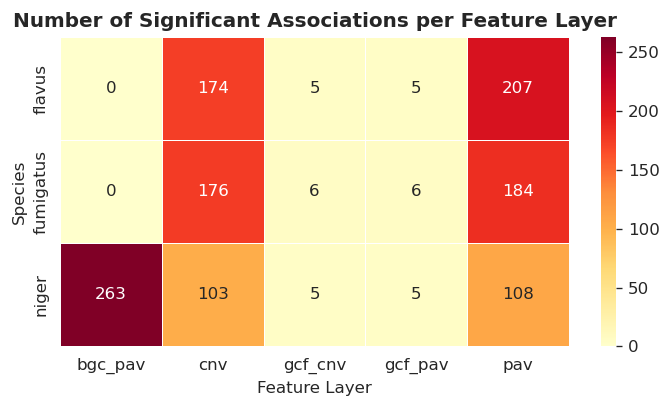

In [22]:
# --- Tweakable parameters ---
FIGSIZE = (6, 3.5)
DPI     = 800

fig_heat, heatmap_df = gwas.plot_significance_heatmap(
    all_results, out_path=NB2_RESULTS / 'summary_heatmap.png',
    figsize=FIGSIZE, dpi=DPI,
)
plt.show()

---
## Section 8: Summary

- Significant associations per species, contrast and feature layer
- Every output file with its full path under `NB2_Results/`

In [23]:
# Standalone bootstrap: run this cell to use Section 8 from a fresh kernel.
import sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
ANALYSIS_DIR = Path('/datadrive/Analysis')
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS  = ANALYSIS_DIR / 'NB2_Results'

# True recomputes from source and ignores every cached table
FORCE = False

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as utils
import funpan_gwas as gwas

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SPECIES           = utils.SPECIES_LIST
FEATURE_LAYERS    = ['pav', 'cnv', 'bgc_pav', 'gcf_pav', 'gcf_cnv']
ANNOTATION_LAYERS = ['COG_category', 'PFAMs', 'CAZy', 'KEGG_ko', 'KEGG_Pathway',
                     'KEGG_TC', 'GOs', 'interpro_IPR', 'EC', 'dbcan_Substrate']
FDR_THRESHOLD     = 0.05

species_data = gwas.load_all_species_gwas_data(
    SPECIES, NB0_RESULTS, NB1_RESULTS, ANNOTATION_LAYERS
)
species_contrasts = gwas.build_all_phenotype_contrasts(
    SPECIES, species_data, NB2_RESULTS, force=FORCE
)
all_results = gwas.run_all_associations(
    SPECIES, species_contrasts, species_data, NB2_RESULTS,
    FEATURE_LAYERS, ANNOTATION_LAYERS, FDR_THRESHOLD, force=FORCE
)

fumigatus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
flavus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
niger: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
oryzae: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
fumigatus: loaded 2 cached contrasts
flavus: loaded 3 cached contrasts
niger: loaded 2 cached contrasts

oryzae -- 0 contrasts:

fumigatus: running association tests

  Contrast: human_pathogenic_vs_rest
    Layer: pav (88 features) ... cached (92 significant)
    Layer: cnv (88 features) ... cached (88 significant)
    Layer: bgc_pav (88 features) ... cached (0 significant)
    Layer: gcf_pav (88 features) ... cached (3 significant)
    Layer: gcf_cnv (88 features) ... cached (3 s

In [24]:
summary_counts, summary_files = gwas.print_nb2_summary(
    all_results, SPECIES, NB2_RESULTS
)
display(summary_counts)

NB2 Pan-GWAS complete.
All outputs saved to: /datadrive/Analysis/NB2_Results
    /datadrive/Analysis/NB2_Results/power_analysis_results.tsv
    /datadrive/Analysis/NB2_Results/power_curves.tsv
    /datadrive/Analysis/NB2_Results/power_analysis_curves.png
    /datadrive/Analysis/NB2_Results/underpowered_contrasts_nonenv.png
    /datadrive/Analysis/NB2_Results/volcano_grid_focus.png
    /datadrive/Analysis/NB2_Results/summary_heatmap.png
    /datadrive/Analysis/NB2_Results/fumigatus/phenotypes/pheno_*.tsv  (2 files)
    /datadrive/Analysis/NB2_Results/fumigatus/pangwas_results/*_assoc_*.tsv  (14 files)
    /datadrive/Analysis/NB2_Results/fumigatus/fumigatus_functional_enrichment.csv
    /datadrive/Analysis/NB2_Results/fumigatus/fumigatus_sig_ogs_in_bgc_detail.csv
    /datadrive/Analysis/NB2_Results/flavus/phenotypes/pheno_*.tsv  (3 files)
    /datadrive/Analysis/NB2_Results/flavus/pangwas_results/*_assoc_*.tsv  (21 files)
    /datadrive/Analysis/NB2_Results/flavus/flavus_functional_enric

bgc_pav  cnv  gcf_cnv  gcf_pav  pav
species   contrast                                                     
flavus    environmental_vs_rest           0   27        0        0   28
          human_pathogenic_vs_rest        0   49        1        1   62
          plant_pathogenic_vs_rest        0   98        4        4  117
fumigatus environmental_vs_rest           0   88        3        3   92
          human_pathogenic_vs_rest        0   88        3        3   92
niger     environmental_vs_rest          87  102        3        3  106
          industrial_trait_vs_rest      176    1        2        2    2